# Accuracy–Latency Pareto Analysis

Produces **Figure 4.2** and the viable-region selection table for Chapter 4.

**Reads** (falls back to the hard-coded tables below if absent)
- `results/latency_pi.json` — measured Raspberry Pi 5 latency
- `results/summary_per_config.csv` — test accuracy, from `96_results_summary.ipynb`

**Writes**
- `figures/fig_4_2_pareto.png` / `.pdf`
- `results/pareto_selection.md` — the selection table, ready to paste

Run top to bottom. Every value is editable in Section 2 if you would rather not
depend on the upstream files.

## 1 · Configuration

In [8]:
# !pip install matplotlib numpy

import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import numpy as np
from matplotlib.lines import Line2D

RESULTS_DIR = Path("../results")     # adjust if running from repo root
FIG_DIR     = Path("../figures")
LATENCY_JSON = RESULTS_DIR / "latency_pi.json"
SUMMARY_CSV  = RESULTS_DIR / "summary_per_config.csv"

PREREGISTERED_LIMIT_S = 60.0    # sub-minute constraint from the project aim
DOMINANCE_TOL_PP      = 1.0     # ~one fold standard error, in F1 points

# Figure options
TWO_PANEL     = False   # add a second panel for TT sensitivity
SHOW_LOSSES   = False   # include the 1D loss variants (diamond markers)
OUT_FORMATS   = ["png", "pdf"]
DPI           = 300

# Palette — consistent with the project's tissue-class colours
C_GREEN, C_RED   = "#5DCAA5", "#D85A30"
C_BLUE, C_GREY   = "#378ADD", "#888780"
C_AMBER, C_INK   = "#E8B84B", "#1E2130"

## 2 · Data

Latency is measured on the Raspberry Pi 5; entries marked `extrap=True` were
timed over a 20,000-pixel subsample and scaled linearly to the full
265,440-pixel image.

Accuracy is test-set macro F1 excluding background, median ± population standard
deviation across the five folds. Configurations excluded on latency alone were
never test-evaluated and carry `nan` — they are reported but cannot be plotted
on the accuracy axis.

In [9]:
NAN = float("nan")

# label, params, latency_s, f1, f1_std, tt_sens, tt_std, tt_f1, extrap, is_loss_variant
CONFIGS = [
    ("1D-NN-Fabelo",       4_936,     0.103,  70.8, 3.2, 62.4,  9.9, 44.6, False, False),
    ("1D-CNN Hu",         76_824,     4.346,  73.3, 2.0, 65.1,  7.7, 55.6, False, False),
    ("2D-CNN-Simple",     19_644,    27.319,  71.4, 4.1, 68.3,  6.2, 43.5, False, False),
    ("1D-NN-Baseline", 17_055_748,  117.233,  68.5, 2.5, 51.4, 15.4, 41.9, True,  False),
    ("2D-CNN-Fabelo",    142_052,   120.259,  75.9, 1.8, 66.5,  4.6, 58.0, False, False),
    # Excluded on measured latency; never test-evaluated.
    ("SF-ViT",           198_197,   903.443,  NAN, 0, NAN, 0, NAN,        True,  False),
    ("SF-CAF",           198_197,  1050.163,  NAN, 0, NAN, 0, NAN,        True,  False),
    ("2D-CNN-LeeEtAl",   296_580,  2688.067,  NAN, 0, NAN, 0, NAN,        True,  False),

    # Loss variants on 1D-NN-Fabelo — same architecture, same latency.
    ("1D-NN-Fabelo (FL)",  4_936,     0.103,  69.9, 4.2, 58.2, 12.3, 44.9, False, True),
    ("1D-NN-Fabelo (UFL)", 4_936,     0.103,  67.4, 3.2, 59.6,  8.7, 39.7, False, True),
    ("1D-NN-Fabelo (DL)",  4_936,     0.103,  61.8, 9.3, 27.4, 21.0, 20.5, False, True),
]

FIELDS = ["label", "params", "latency_s", "f1", "f1_std",
          "tt_sens", "tt_std", "tt_f1", "extrap", "is_loss"]
DATA = [dict(zip(FIELDS, c)) for c in CONFIGS]

print(f"{len(DATA)} configurations defined "
      f"({sum(not d['is_loss'] for d in DATA)} architectures, "
      f"{sum(d['is_loss'] for d in DATA)} loss variants)")

11 configurations defined (8 architectures, 3 loss variants)


## 3 · Cross-check against the measurement files

Optional. If `results/latency_pi.json` is present, every hard-coded latency is
compared against it and any disagreement is reported — a guard against the
table above drifting out of date after a re-measurement.

In [10]:
def crosscheck_latency():
    if not LATENCY_JSON.exists():
        print(f"{LATENCY_JSON} not found — using the hard-coded table.")
        return
    payload = json.loads(LATENCY_JSON.read_text())
    print(f"Device: {payload.get('device', 'unknown')}")
    print(f"Image : {payload.get('image', '?')} "
          f"({payload.get('total_pixels', 0):,} px)")
    if payload.get("complete") is False:
        print("WARNING: that run did not finish — some rows may be missing.")
    print()

    measured = {}
    for r in payload.get("results", []):
        key = r["label"].replace(" (CE)", "").strip()
        measured[key] = r["median_s"]

    def norm(s):
        return (s.replace("SF-", "SpectralFormer-")
                 .replace("1D-CNN Hu", "1D-CNN Hu").strip())

    mismatches = 0
    for d in DATA:
        if d["is_loss"]:
            continue
        want = norm(d["label"])
        hit = next((v for k, v in measured.items()
                    if norm(k).lower() == want.lower()), None)
        if hit is None:
            print(f"  {d['label']:<18} not in latency file")
        elif abs(hit - d["latency_s"]) > 0.01:
            print(f"  {d['label']:<18} table {d['latency_s']:>10.3f}s  "
                  f"file {hit:>10.3f}s   <-- DIFFERS")
            mismatches += 1
        else:
            print(f"  {d['label']:<18} {d['latency_s']:>10.3f}s  ok")
    print()
    print("All latencies match the measurement file." if not mismatches
          else f"{mismatches} value(s) differ — update Section 2.")


crosscheck_latency()

../results/latency_pi.json not found — using the hard-coded table.


## 4 · Selection rule

Stated before the analysis and applied without exception.

A configuration is **viable** if its measured whole-image latency on the target
hardware is below the clinical constraint. A viable configuration is
**Pareto-optimal** if no other viable configuration beats it on macro F1
excluding background *and* on latency, where "beats" on accuracy means by more
than `DOMINANCE_TOL_PP` — roughly one fold standard error, so that noise-level
differences do not eliminate candidates spuriously.

Knee-point selection was considered and rejected: the position of a knee depends
on axis scaling, and the method is undefined on a frontier of fewer than three
points. Where one objective has a hard threshold, constraint satisfaction is the
appropriate mechanism.

In [11]:
# Graded refinement of the pre-registered 60 s bound.
TIERS = [
    ("Interactive",         0.0,   1.0, C_GREEN, 0.13),
    ("Responsive",          1.0,   5.0, C_GREEN, 0.07),
    ("Workflow-compatible", 5.0,  30.0, C_AMBER, 0.09),
    ("Disruptive",         30.0, 1e5,   C_RED,   0.09),
]


def tier_of(latency):
    for name, lo, hi, _, _ in TIERS:
        if lo <= latency < hi:
            return name
    return TIERS[-1][0]


def pareto_front(points, tol=0.0):
    """Indices of non-dominated (latency, accuracy) points; lower x, higher y."""
    keep = []
    for i, (xi, yi) in enumerate(points):
        dominated = any(
            (xj <= xi) and (yj >= yi + tol) and ((xj < xi) or (yj > yi + tol))
            for j, (xj, yj) in enumerate(points) if j != i
        )
        if not dominated:
            keep.append(i)
    return keep

## 5 · Viable region and frontier

In [12]:
arch = [d for d in DATA if not d["is_loss"]]

# Split by whether the configuration can be plotted on the accuracy axis
plottable   = [d for d in arch if not np.isnan(d["f1"])]
unevaluated = [d for d in arch if np.isnan(d["f1"])]

if unevaluated:
    print("Excluded on measured latency; never test-evaluated:")
    for d in sorted(unevaluated, key=lambda d: d["latency_s"]):
        print(f"  {d['label']:<18} {d['latency_s']:>10.1f}s   "
              f"{d['latency_s'] / PREREGISTERED_LIMIT_S:>4.0f}x the "
              f"{PREREGISTERED_LIMIT_S:.0f}s constraint")
    print()

viable_idx = [i for i, d in enumerate(plottable)
              if d["latency_s"] < PREREGISTERED_LIMIT_S]
front_local = pareto_front(
    [(plottable[i]["latency_s"], plottable[i]["f1"]) for i in viable_idx],
    tol=DOMINANCE_TOL_PP,
)
FRONT = {viable_idx[i] for i in front_local}

def verdict(i, d):
    if d["latency_s"] >= PREREGISTERED_LIMIT_S:
        return "EXCLUDED - exceeds constraint"
    return "PARETO-OPTIMAL" if i in FRONT else "dominated"

print(f"Viable-region analysis (dominance tolerance {DOMINANCE_TOL_PP:.1f} pp)")
print()
print(f"  {'Configuration':<18}{'Latency':>10}  {'Tier':<22}"
      f"{'F1-noBG':>9}{'TT sens':>9}  Verdict")
print("  " + "-" * 88)
for i, d in enumerate(sorted(plottable, key=lambda d: d["latency_s"])):
    j = plottable.index(d)
    print(f"  {d['label']:<18}{d['latency_s']:>9.2f}s  {tier_of(d['latency_s']):<22}"
          f"{d['f1']:>8.1f}%{d['tt_sens']:>8.1f}%  {verdict(j, d)}")

rec = max((plottable[i] for i in FRONT), key=lambda d: d["f1"])
print()
print(f"  Recommended: {rec['label']} — {rec['f1']:.1f}% F1-noBG at "
      f"{rec['latency_s']:.3f}s ({tier_of(rec['latency_s'])} tier)")

Excluded on measured latency; never test-evaluated:
  SF-ViT                  903.4s     15x the 60s constraint
  SF-CAF                 1050.2s     18x the 60s constraint
  2D-CNN-LeeEtAl         2688.1s     45x the 60s constraint

Viable-region analysis (dominance tolerance 1.0 pp)

  Configuration        Latency  Tier                    F1-noBG  TT sens  Verdict
  ----------------------------------------------------------------------------------------
  1D-NN-Fabelo           0.10s  Interactive               70.8%    62.4%  PARETO-OPTIMAL
  1D-CNN Hu              4.35s  Responsive                73.3%    65.1%  PARETO-OPTIMAL
  2D-CNN-Simple         27.32s  Workflow-compatible       71.4%    68.3%  dominated
  1D-NN-Baseline       117.23s  Disruptive                68.5%    51.4%  EXCLUDED - exceeds constraint
  2D-CNN-Fabelo        120.26s  Disruptive                75.9%    66.5%  EXCLUDED - exceeds constraint

  Recommended: 1D-CNN Hu — 73.3% F1-noBG at 4.346s (Responsive tier)


## 6 · Figure 4.2

  written -> ../figures/fig_4_2_pareto.png
  written -> ../figures/fig_4_2_pareto.pdf


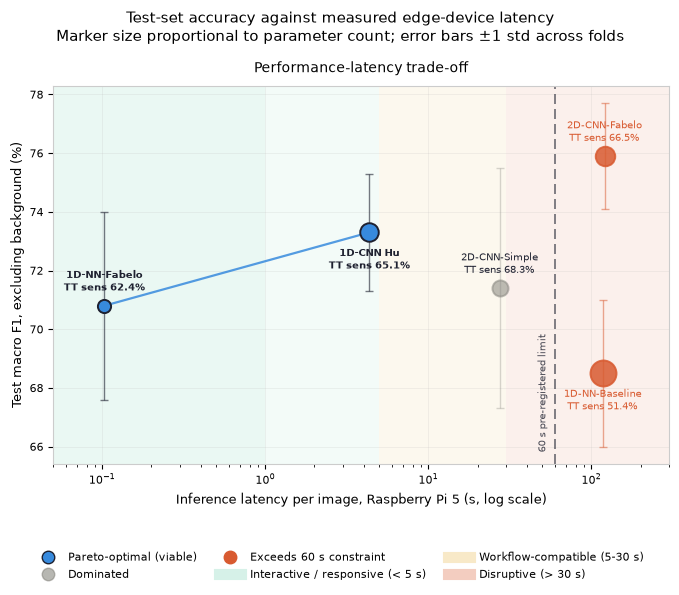

In [13]:
def draw_panel(ax, rows, front, ykey, ystdkey, ylabel, title, annotate_tt):
    lat = np.array([r["latency_s"] for r in rows])
    acc = np.array([r[ykey] for r in rows])
    std = np.array([r[ystdkey] for r in rows])
    par = np.array([r["params"] for r in rows])

    xmin, xmax = 0.05, max(lat.max() * 2.2, 300)
    for name, lo, hi, colour, alpha in TIERS:
        ax.axvspan(max(lo, xmin), min(hi, xmax), color=colour,
                   alpha=alpha, zorder=0, linewidth=0)

    ax.axvline(PREREGISTERED_LIMIT_S, color=C_INK, linestyle=(0, (6, 3)),
               linewidth=1.2, zorder=2, alpha=0.65)
    blend = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(PREREGISTERED_LIMIT_S * 0.9, 0.03,
            f"{PREREGISTERED_LIMIT_S:.0f} s pre-registered limit",
            rotation=90, va="bottom", ha="right", fontsize=7.5,
            color=C_INK, alpha=0.8, zorder=6, transform=blend)

    front_sorted = sorted(front, key=lambda i: lat[i])
    if len(front_sorted) > 1:
        ax.plot(lat[front_sorted], acc[front_sorted], "-",
                color=C_BLUE, linewidth=1.6, alpha=0.85, zorder=3)

    lo_p, hi_p = np.log10(par.min()), np.log10(par.max())
    sizes = 90 + 260 * (np.log10(par) - lo_p) / max(hi_p - lo_p, 1e-9)

    for i, r in enumerate(rows):
        on_front = i in front
        fails    = lat[i] >= PREREGISTERED_LIMIT_S
        if fails:
            face = edge = C_RED; alpha = 0.85
        elif on_front:
            face, edge, alpha = C_BLUE, C_INK, 1.0
        else:
            face = edge = C_GREY; alpha = 0.55

        ax.errorbar(lat[i], acc[i], yerr=std[i], fmt="none", ecolor=edge,
                    elinewidth=1.0, capsize=3, alpha=alpha * 0.6, zorder=4)
        ax.scatter(lat[i], acc[i], s=sizes[i], c=face, edgecolors=edge,
                   linewidths=1.4, zorder=5, alpha=alpha,
                   marker="D" if r["is_loss"] else "o")

        label = r["label"]
        if annotate_tt and not r["is_loss"]:
            label += f"\nTT sens {r['tt_sens']:.1f}%"
        ax.annotate(label, (lat[i], acc[i]), textcoords="offset points",
                    xytext=(0, 11 if i % 2 == 0 else -26), ha="center",
                    fontsize=7.5, color=C_RED if fails else C_INK,
                    fontweight="bold" if on_front else "normal", zorder=6)

    ax.set_xscale("log")
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Inference latency per image, Raspberry Pi 5 (s, log scale)",
                  fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, pad=10)
    ax.grid(alpha=0.18, linewidth=0.6)
    ax.tick_params(labelsize=8)
    for sp in ax.spines.values():
        sp.set_color("#CCCCCC")


rows = plottable + ([d for d in DATA if d["is_loss"]] if SHOW_LOSSES else [])
# Recompute the frontier over the plotted set
v = [i for i, d in enumerate(rows) if d["latency_s"] < PREREGISTERED_LIMIT_S
     and not d["is_loss"]]
fl = pareto_front([(rows[i]["latency_s"], rows[i]["f1"]) for i in v],
                  tol=DOMINANCE_TOL_PP)
front = {v[i] for i in fl}

n = 2 if TWO_PANEL else 1
fig, axes = plt.subplots(1, n, figsize=(7.0 * n, 5.9))
axes = np.atleast_1d(axes)

draw_panel(axes[0], rows, front, "f1", "f1_std",
           "Test macro F1, excluding background (%)",
           "Performance-latency trade-off", annotate_tt=not TWO_PANEL)
if TWO_PANEL:
    draw_panel(axes[1], rows, front, "tt_sens", "tt_std",
               "Tumour tissue sensitivity (%)",
               "Clinical priority metric", annotate_tt=False)

handles = [
    Line2D([], [], marker="o", ls="", ms=9, markerfacecolor=C_BLUE,
           markeredgecolor=C_INK, label="Pareto-optimal (viable)"),
    Line2D([], [], marker="o", ls="", ms=9, markerfacecolor=C_GREY,
           markeredgecolor=C_GREY, alpha=0.6, label="Dominated"),
    Line2D([], [], marker="o", ls="", ms=9, markerfacecolor=C_RED,
           markeredgecolor=C_RED,
           label=f"Exceeds {PREREGISTERED_LIMIT_S:.0f} s constraint"),
]
if SHOW_LOSSES:
    handles.append(Line2D([], [], marker="D", ls="", ms=8,
                          markerfacecolor=C_GREY, markeredgecolor=C_GREY,
                          label="Loss variant (same architecture)"))
handles += [
    Line2D([], [], color=C_GREEN, lw=8, alpha=0.25,
           label="Interactive / responsive (< 5 s)"),
    Line2D([], [], color=C_AMBER, lw=8, alpha=0.30,
           label="Workflow-compatible (5-30 s)"),
    Line2D([], [], color=C_RED, lw=8, alpha=0.30,
           label="Disruptive (> 30 s)"),
]
fig.legend(handles=handles, loc="lower center", ncol=3 if n == 1 else 4,
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.005))

fig.suptitle("Test-set accuracy against measured edge-device latency\n"
             "Marker size proportional to parameter count; "
             "error bars ±1 std across folds", fontsize=11)
fig.subplots_adjust(top=0.85, bottom=0.21, left=0.09, right=0.97, wspace=0.22)

FIG_DIR.mkdir(parents=True, exist_ok=True)
for fmt in OUT_FORMATS:
    p = FIG_DIR / f"fig_4_2_pareto.{fmt}"
    fig.savefig(p, dpi=DPI, facecolor="white")
    print(f"  written -> {p}")

plt.show()

## 7 · Export the selection table

In [14]:
out = RESULTS_DIR / "pareto_selection.md"
with open(out, "w") as f:
    f.write("### Viability and dominance\n\n")
    f.write(f"Selection rule: viable if measured Raspberry Pi 5 latency < "
            f"{PREREGISTERED_LIMIT_S:.0f} s; Pareto-optimal if not beaten on "
            f"both accuracy (by more than {DOMINANCE_TOL_PP:.1f} pp) and "
            f"latency.\n\n")
    f.write("| Configuration | F1-noBG (%) | Latency (s) | Tier | Verdict |\n")
    f.write("|---|---|---|---|---|\n")
    for d in sorted(arch, key=lambda d: d["latency_s"]):
        if np.isnan(d["f1"]):
            acc, verd = "not evaluated", "Excluded - latency"
        else:
            j = plottable.index(d)
            acc = f"{d['f1']:.1f} ± {d['f1_std']:.1f}"
            verd = verdict(j, d)
            verd = ("**Pareto-optimal**" if verd == "PARETO-OPTIMAL"
                    else "Dominated" if verd == "dominated"
                    else "Excluded - latency")
        f.write(f"| {d['label']} | {acc} | {d['latency_s']:,.3f} | "
                f"{tier_of(d['latency_s'])} | {verd} |\n")
    f.write("\nRecommended configuration: **" + rec["label"] + "** at "
            f"{rec['f1']:.1f} ± {rec['f1_std']:.1f}% macro F1 excluding "
            f"background and {rec['latency_s']:.3f} s per whole image.\n")

print(f"  written -> {out}")
print()
print(out.read_text())

  written -> ../results/pareto_selection.md

### Viability and dominance

Selection rule: viable if measured Raspberry Pi 5 latency < 60 s; Pareto-optimal if not beaten on both accuracy (by more than 1.0 pp) and latency.

| Configuration | F1-noBG (%) | Latency (s) | Tier | Verdict |
|---|---|---|---|---|
| 1D-NN-Fabelo | 70.8 ± 3.2 | 0.103 | Interactive | **Pareto-optimal** |
| 1D-CNN Hu | 73.3 ± 2.0 | 4.346 | Responsive | **Pareto-optimal** |
| 2D-CNN-Simple | 71.4 ± 4.1 | 27.319 | Workflow-compatible | Dominated |
| 1D-NN-Baseline | 68.5 ± 2.5 | 117.233 | Disruptive | Excluded - latency |
| 2D-CNN-Fabelo | 75.9 ± 1.8 | 120.259 | Disruptive | Excluded - latency |
| SF-ViT | not evaluated | 903.443 | Disruptive | Excluded - latency |
| SF-CAF | not evaluated | 1,050.163 | Disruptive | Excluded - latency |
| 2D-CNN-LeeEtAl | not evaluated | 2,688.067 | Disruptive | Excluded - latency |

Recommended configuration: **1D-CNN Hu** at 73.3 ± 2.0% macro F1 excluding background and 4.346 s pe